In [15]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.io # Para cargar archivos .mat
from scipy import signal, stats # Para procesamiento de señales
from sklearn.preprocessing import StandardScaler # Para normalizar los datos
from tensorflow.keras.utils import to_categorical # Para convertir etiquetas a one-hot
import joblib # Para guardar el Scaler

In [16]:
ruta_archivo = '../datasets/raw/s1/S1_E2_A1.mat'
mat_data = scipy.io.loadmat(ruta_archivo)

In [17]:
# Extraer las variables relevantes
emg = mat_data['emg'][:, 0:8]
gestos = mat_data['restimulus'] 
repeticiones = mat_data['rerepetition']

print(emg.shape)

(179901, 8)


In [18]:
# Cortar la información a los 6 gestos relevantes
idx_gesto_7 = np.where(gestos == 7)[0]
print(idx_gesto_7)

idx_corte = idx_gesto_7[0] if len(idx_gesto_7) > 0 else len(gestos)

emg_corte = emg[:idx_corte]
gestos_corte = gestos[:idx_corte]
reps_corte = repeticiones[:idx_corte]

[65417 65418 65419 ... 74770 74771 74772]


In [19]:
# Segundo filtro: Solo quedarnos con los gestos 0-6
target_classes = [0, 1, 2, 3, 4, 5, 6]

mask_limpieza = (gestos_corte <= 6).flatten()
mask_gestos = np.isin(gestos_corte, target_classes).flatten()
mask_a_clasificar = np.logical_and(mask_limpieza, mask_gestos)

gestos_filtrado = gestos_corte[mask_a_clasificar]
print(gestos_filtrado.shape)
repeticiones_filtrado = reps_corte[mask_a_clasificar]
print(repeticiones_filtrado.shape)
emg_filtrado = emg_corte[mask_a_clasificar]
print(emg_filtrado.shape)

(65417, 1)
(65417, 1)
(65417, 8)


In [20]:
# Conteo de filas por cada gesto
gestos_unicos, conteos = np.unique(gestos_filtrado, return_counts=True)
df_conteo = pd.DataFrame({'Gesto': gestos_unicos, 'Total_Filas': conteos})
print(df_conteo)

   Gesto  Total_Filas
0      0        38774
1      1         5345
2      2         3965
3      3         4389
4      4         4597
5      5         4266
6      6         4081


In [21]:
# target = 0
# mask_target = (gestos == target)

# mask_reposo = (gestos == 0)

# reps_en_reposo = repeticiones[mask_reposo]

# reps_unicas_reposo, conteos_reposo = np.unique(reps_en_reposo, return_counts=True)

# print("\n--- ANÁLISIS DEL REPOSO ---")
# print("Cuando Gestos es 0, Repetición toma estos valores:")
# df_reposo = pd.DataFrame({'Rerepetition': reps_unicas_reposo, 'Cantidad': conteos_reposo})
# print(df_reposo)

In [22]:
# # Crear máscaras para entrenamiento y prueba basadas en las repeticiones
# reps_entrenamiento = [1, 3, 4, 6]
# reps_prueba = [2, 5]

# mask_train = np.isin(repeticiones_filtrado, reps_entrenamiento).flatten()
# mask_test = np.isin(repeticiones_filtrado, reps_prueba).flatten()

# X_train_raw = emg_filtrado[mask_train]
# X_test_raw  = emg_filtrado[mask_test]

# y_train_raw = gestos_filtrado[mask_train]
# y_test_raw  = gestos_filtrado[mask_test]


# print(f"Total filas originales: {emg_filtrado.shape[0]}")
# print(f"Filas para Train (Reps 1,3,4,6): {X_train_raw.shape[0]}")
# print(f"Filas para Test  (Reps 2,5):    {X_test_raw.shape[0]}")

# print(f"Suma: {X_train_raw.shape[0] + X_test_raw.shape[0]}")

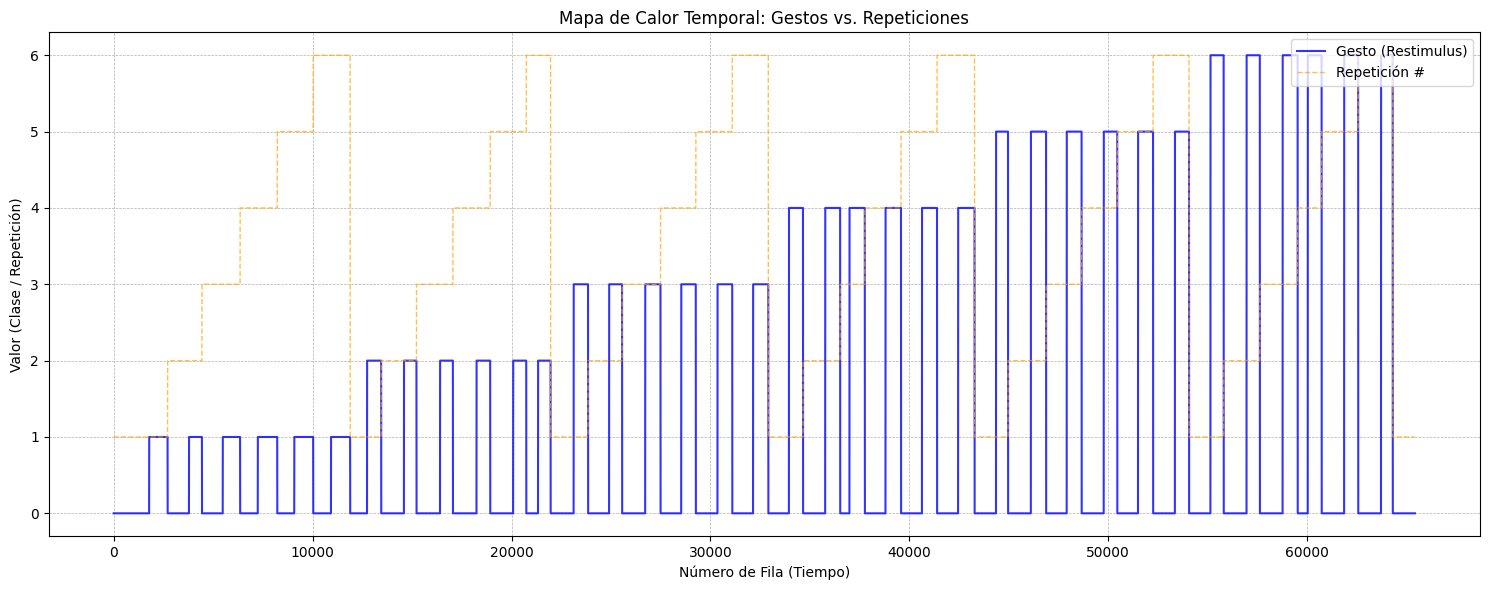

In [23]:
# Graficar la evolución temporal de los gestos y repeticiones
plt.figure(figsize=(15, 6))

plt.plot(gestos_filtrado, label='Gesto (Restimulus)', color='blue', linewidth=1.5, alpha=0.8)

plt.plot(repeticiones_filtrado, label='Repetición #', color='orange', linestyle='--', linewidth=1, alpha=0.7)

plt.title("Mapa de Calor Temporal: Gestos vs. Repeticiones")
plt.xlabel("Número de Fila (Tiempo)")
plt.ylabel("Valor (Clase / Repetición)")
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# plt.xlim(0, 5000) 

plt.tight_layout()
plt.show()

In [24]:
# Filtro Butterworth Pasa-Banda de 4to orden
def pasa_banda(emg_data, fs=200):
    """
    Aplica un filtro Butterworth pasa-banda a los datos EMG.
        fs: Frecuencia de muestreo (Hz)
        Retorna los datos filtrados.
    """
    # Corta entre 20Hz (movimiento) y 90Hz (ruido alto/aliasing)
    nyquist = 0.5 * fs
    low = 20 / nyquist
    high = 90 / nyquist
    b, a = signal.butter(4, [low, high], btype='band')
    
    # filtfilt (filtro de fase cero) para no desfasar la señal
    emg_clean = signal.filtfilt(b, a, emg_data, axis=0)
    return emg_clean

In [25]:
# Filtro Pasa-Banda entre 20Hz y 90Hz
emg_bandpass = pasa_banda(emg_filtrado)

# Rectificación
emg_rectificado = np.abs(emg_bandpass)

emg_rectificado.shape

(65417, 8)

In [26]:
def create_windows_matrix(emg_data, labels, reps, window_size=40, step_size=10):
    """
    Transforma la señal continua en ventanas 3D para la CNN-LSTM.
    Retorna:
    - X: (N_ventanas, 40, 8)
    - y: (N_ventanas,)
    - r: (N_ventanas,) -> Para saber qué repetición es cada ventana
    """
    X_list = []
    y_list = []
    r_list = []
    
    # Recorre la señal dando saltos de 'step_size'
    limit = len(emg_data) - window_size # Para no salirse del array
    
    for i in range(0, limit, step_size):
        # 1. Cortamos la ventana de EMG (La "foto" de 40 muestras)
        window = emg_data[i : i + window_size]
        
        # 2. Obtenemos la etiqueta (La moda: el valor que más se repite en esos 200ms)
        # Usamos stats.mode para ser estadísticamente correctos
        # .mode devuelve un objeto, [0] es el valor
        label_mode = stats.mode(labels[i : i + window_size], keepdims=True)[0][0]
        rep_mode = stats.mode(reps[i : i + window_size], keepdims=True)[0][0]
        
        X_list.append(window)
        y_list.append(label_mode)
        r_list.append(rep_mode)
        
    return np.array(X_list), np.array(y_list), np.array(r_list)

In [27]:
# Crear las ventanas para la CNN-LSTM
X_raw, y_raw, r_raw = create_windows_matrix(
    emg_rectificado,
    gestos_filtrado, 
    repeticiones_filtrado, 
    window_size=40, 
    step_size=10
)

print(f"Forma de X (Entrada Red): {X_raw.shape}  <- (Ventanas, Tiempo, Sensores)")
print(f"Forma de y (Etiquetas):   {y_raw.shape}")
print(f"Forma de r (Repeticiones): {r_raw.shape}")

Forma de X (Entrada Red): (6538, 40, 8)  <- (Ventanas, Tiempo, Sensores)
Forma de y (Etiquetas):   (6538, 1)
Forma de r (Repeticiones): (6538, 1)


In [28]:
# SPLIT TRAIN-TEST BASADO EN REPETICIONES para evitar Data Leakage
reps_train = [1, 3, 4, 6]
reps_test  = [2, 5]

# Usar el array de repeticiones para hacer las máscaras
mask_train = np.isin(r_raw, reps_train).flatten()
mask_test  = np.isin(r_raw, reps_test).flatten()

# 2. APLICAMOS EL SPLIT
X_train = X_raw[mask_train]
y_train = y_raw[mask_train]

X_test  = X_raw[mask_test]
y_test  = y_raw[mask_test]

# 3. NORMALIZACIÓN (StandardScaler)
# Truco pro: Escalamos sobre (N*40, 8) porque el scaler pide 2D
# ¡IMPORTANTE! El scaler se entrena (fit) SOLO con X_train para no hacer trampa
scaler = StandardScaler()

# Aplanamos temporalmente para normalizar
N_train, Time, Feat = X_train.shape
N_test = X_test.shape[0]

X_train_flat = X_train.reshape(N_train * Time, Feat)
X_test_flat  = X_test.reshape(N_test * Time, Feat)

# Calculamos media y desv. est. solo con Train
scaler.fit(X_train_flat)

# Transformamos ambos
X_train_scaled = scaler.transform(X_train_flat).reshape(N_train, Time, Feat)
X_test_scaled  = scaler.transform(X_test_flat).reshape(N_test, Time, Feat)

print(f"--- SPLIT ---")
print(f"Train set: {X_train_scaled.shape}")
print(f"Test set:  {X_test_scaled.shape}")


print(f"--- NORMALIZACIÓN ---")
print(f"Media de Train (aprox 0): {np.mean(X_train_scaled):.2f}")
print(f"Std de Train (aprox 1):   {np.std(X_train_scaled):.2f}")

# 4. ONE-HOT ENCODING (Etiquetas)
# Convierte 3 -> [0,0,0,1,0,0,0]
# num_classes = 7 (Gestos 0 a 6)
num_classes = 7 
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print(f"--- LISTO ---")
print(f"Forma final y_train: {y_train_cat.shape}")

--- SPLIT ---
Train set: (4367, 40, 8)
Test set:  (2171, 40, 8)
--- NORMALIZACIÓN ---
Media de Train (aprox 0): 0.00
Std de Train (aprox 1):   1.00
--- LISTO ---
Forma final y_train: (4367, 7)


In [29]:
# Definir ruta
base_path = '../datasets/processed'

# Crear carpeta si no existe
if not os.path.exists(base_path):
    os.makedirs(base_path)
    print(f"Carpeta creada: {base_path}")

# Guardar los Tensores (Datos Crudos listos para DL)
# .npy porque es el formato nativo de numpy (rápido y soporta 3D)
np.save(os.path.join(base_path, 'X_train.npy'), X_train_scaled)
np.save(os.path.join(base_path, 'y_train.npy'), y_train_cat)
np.save(os.path.join(base_path, 'X_test.npy'),  X_test_scaled)
np.save(os.path.join(base_path, 'y_test.npy'),  y_test_cat)

print("Tensores X e y guardados exitosamente.")

# Guardar el Scaler (¡VITAL PARA EL ROBOT EN VIVO!)
scaler_path = os.path.join(base_path, 'std_scaler.bin')
joblib.dump(scaler, scaler_path)

print(f"Scaler guardado en: {scaler_path}")

Tensores X e y guardados exitosamente.
Scaler guardado en: ../datasets/processed/std_scaler.bin
